<a href="https://colab.research.google.com/github/JaviSantosM/Economia3/blob/main/Taxis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Librerías

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sea
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import datetime as dt
from statsmodels.tsa.seasonal import seasonal_decompose
import re

#Conectar a Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Guardar

In [ ]:
df.to_csv('/content/drive/MyDrive/taxisdataset.csv')

#Cargar

In [ ]:
df_raw=pd.read_csv("/content/drive/MyDrive/yellow_tripdata_2020-03.csv")

/tmp/ipykernel_1966/227487301.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw=pd.read_csv("/content/drive/MyDrive/yellow_tripdata_2020-03.csv")


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/taxisdataset.csv")

#Selección aleatoria de 200k muestras

In [ ]:
df=df_raw.sample(n=200000,random_state=42)

#Codigo

In [ ]:
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,trip_duration
0,145215,2.0,2020-03-01 18:10:56,2020-03-01 18:24:14,1.0,6.27,1.0,N,48,244,1.0,19.5,0.0,0.5,4.56,0.0,0.3,27.36,2.5,13.30
1,854435,1.0,2020-03-05 08:32:54,2020-03-05 08:38:54,1.0,1.00,1.0,N,161,48,1.0,6.0,2.5,0.5,1.00,0.0,0.3,10.30,2.5,6.00
2,888841,2.0,2020-03-05 11:25:51,2020-03-05 11:34:09,1.0,1.58,1.0,N,79,170,2.0,8.0,0.0,0.5,0.00,0.0,0.3,11.30,2.5,8.30
3,828781,1.0,2020-03-05 05:32:33,2020-03-05 05:36:42,2.0,0.70,1.0,N,48,161,2.0,5.0,3.0,0.5,0.00,0.0,0.3,8.80,2.5,4.15
4,509648,2.0,2020-03-03 17:52:33,2020-03-03 17:59:39,1.0,0.40,1.0,N,100,170,2.0,6.0,1.0,0.5,0.00,0.0,0.3,10.30,2.5,7.10


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 197500 entries, 0 to 199999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Unnamed: 0             197500 non-null  int64         
 1   VendorID               197500 non-null  float64       
 2   tpep_pickup_datetime   197500 non-null  datetime64[ns]
 3   tpep_dropoff_datetime  197500 non-null  datetime64[ns]
 4   passenger_count        197500 non-null  float64       
 5   trip_distance          197500 non-null  float64       
 6   RatecodeID             197500 non-null  float64       
 7   store_and_fwd_flag     197500 non-null  object        
 8   PULocationID           197500 non-null  int64         
 9   DOLocationID           197500 non-null  int64         
 10  payment_type           197500 non-null  float64       
 11  fare_amount            197500 non-null  float64       
 12  extra                  197500 non-null  float64  

In [ ]:
df.describe()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,trip_duration,hour
count,1.975000e+05,197500.000000,197500,197500,197500.000000,197500.000000,197500.000000,197500.000000,197500.000000,197500.000000,197500.000000,197500.000000,197500.000000,197500.000000,197500.000000,197500.000000,197500.000000,197500.000000,197500.000000,197500.000000
mean,1.485587e+06,1.664643,2020-03-09 01:09:07.214632704,2020-03-09 01:24:34.381255680,1.472354,2.815099,1.052623,163.880800,161.465327,1.266603,12.312702,1.097955,0.493430,2.168921,0.283755,0.297633,18.164089,2.270071,15.452777,13.745919
min,1.200000e+01,1.000000,2009-01-01 00:08:35,2009-01-01 00:27:46,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-170.000000,-4.500000,-0.500000,-87.770000,-12.240000,-0.300000,-170.300000,-2.500000,0.000000,0.000000
25%,7.417965e+05,1.000000,2020-03-04 18:18:18,2020-03-04 18:34:15.500000,1.000000,0.990000,1.000000,116.000000,107.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,11.160000,2.500000,6.200000,10.000000
50%,1.487834e+06,2.000000,2020-03-07 22:16:00.500000,2020-03-07 22:31:20,1.000000,1.640000,1.000000,162.000000,162.000000,1.000000,9.000000,0.500000,0.500000,1.950000,0.000000,0.300000,14.300000,2.500000,10.300000,14.000000
75%,2.232373e+06,2.000000,2020-03-12 08:16:54.249999872,2020-03-12 08:31:23.750000128,1.000000,2.970000,1.000000,234.000000,234.000000,2.000000,13.500000,2.500000,0.500000,2.860000,0.000000,0.300000,19.750000,2.500000,16.600000,18.000000
max,2.969778e+06,2.000000,2020-06-28 16:10:56,2020-06-28 16:14:52,6.000000,310.900000,99.000000,265.000000,265.000000,4.000000,804.000000,7.000000,0.500000,222.110000,70.000000,0.300000,1023.670000,2.500000,1439.600000,23.000000
std,8.581793e+05,0.472116,NaN,NaN,1.124771,3.652609,0.777952,66.378641,70.479664,0.476031,11.488579,1.246819,0.070611,2.643798,1.484328,0.036638,13.974287,0.745524,59.883266,5.777787


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0


In [ ]:
df=df.dropna()

In [ ]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [ ]:
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

In [ ]:
df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['day'] = df['tpep_pickup_datetime'].dt.day_name()

##Duracion de viajes

In [ ]:
df[(df.trip_duration<5)]

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,trip_duration
3,828781,1.0,2020-03-05 05:32:33,2020-03-05 05:36:42,2.0,0.70,1.0,N,48,161,2.0,5.0,3.0,0.5,0.00,0.00,0.3,8.80,2.5,4.150000
5,2685883,2.0,2020-03-16 12:10:41,2020-03-16 12:14:15,1.0,0.52,1.0,N,237,237,1.0,4.5,0.0,0.5,2.34,0.00,0.3,10.14,2.5,3.566667
10,637157,1.0,2020-03-04 09:55:01,2020-03-04 09:56:18,1.0,0.10,1.0,N,211,144,1.0,3.0,2.5,0.5,1.25,0.00,0.3,7.55,2.5,1.283333
19,2387041,2.0,2020-03-13 06:29:36,2020-03-13 06:34:14,1.0,1.69,1.0,N,90,230,1.0,6.5,0.0,0.5,1.96,0.00,0.3,11.76,2.5,4.633333
20,122714,2.0,2020-03-01 16:11:57,2020-03-01 16:14:06,1.0,0.57,1.0,N,237,237,1.0,4.0,0.0,0.5,1.46,0.00,0.3,8.76,2.5,2.150000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199945,730144,2.0,2020-03-04 17:43:50,2020-03-04 17:46:46,5.0,0.40,1.0,N,239,239,2.0,4.0,1.0,0.5,0.00,0.00,0.3,8.30,2.5,2.933333
199954,1341442,2.0,2020-03-07 09:01:13,2020-03-07 09:04:13,2.0,0.45,1.0,N,239,238,1.0,4.0,0.0,0.5,0.73,0.00,0.3,8.03,2.5,3.000000
199965,2032473,2.0,2020-03-11 01:05:37,2020-03-11 01:08:06,1.0,0.95,1.0,N,246,48,1.0,5.0,0.5,0.5,1.00,0.00,0.3,9.80,2.5,2.483333
199984,1130330,2.0,2020-03-06 11:13:56,2020-03-06 11:16:24,1.0,0.42,1.0,N,239,239,1.0,4.0,0.0,0.5,1.00,0.00,0.3,8.30,2.5,2.466667


In [ ]:
Q1=df["trip_duration"].quantile(0.25)
Q3=df["trip_duration"].quantile(0.75)
IQR=Q3-Q1
proporcion=1.5
li=Q1-1.5 * IQR
ls=Q3+1.5 *IQR

In [ ]:
li

np.float64(-9.400000000000002)

In [ ]:
ls

np.float64(32.2)

In [ ]:
df_outlier=df.loc[(df.trip_duration<li) | (df.trip_duration>ls)]
df_outlier.shape

(9805, 22)

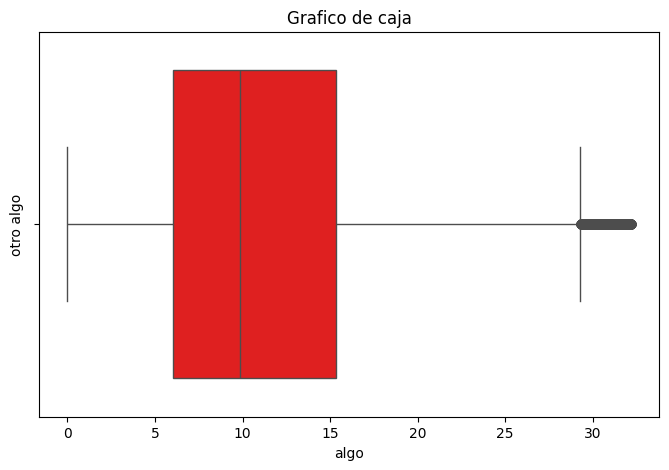

In [ ]:
plt.figure(figsize=(8,5))
sea.boxplot(x=df_cleantd["trip_duration"], color="red")
plt.title("Grafico de caja")
plt.xlabel("algo")
plt.ylabel("otro algo")
plt.show()

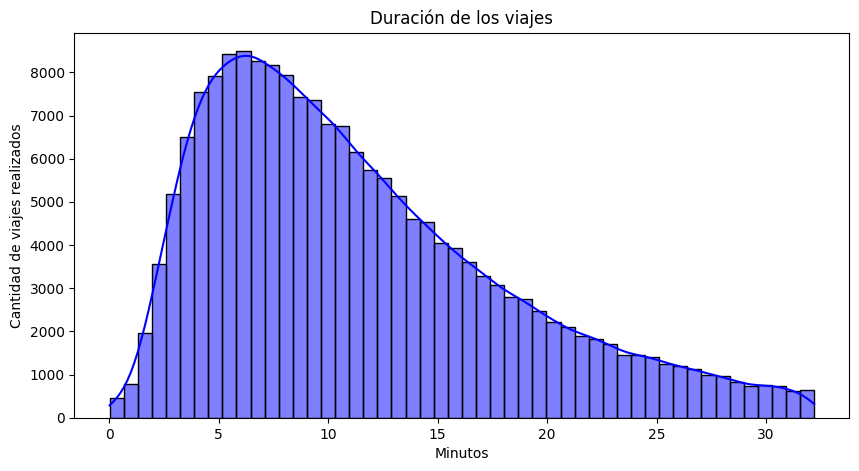

In [ ]:
plt.figure(figsize=(10,5))
sea.histplot(df_cleantd['trip_duration'], bins = 50, kde = True, color = 'blue')
plt.title("Duración de los viajes")
plt.xlabel("Minutos")
plt.ylabel("Cantidad de viajes realizados")
plt.show()

In [ ]:
df_cleantd['trip_duration'].mean()


np.float64(11.418645941352693)

In [ ]:
df_cleantd = df_cleantd[(df_cleantd['trip_distance'] > 0) & (df_cleantd['fare_amount'] > 0) & (df_cleantd['trip_duration'] > 0)]

<Axes: xlabel='hour'>

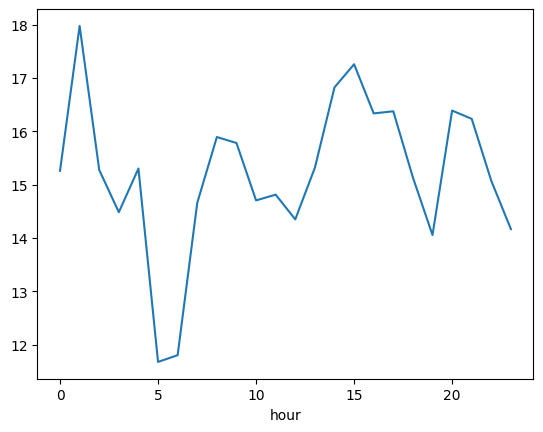

In [ ]:
df.groupby('hour')['trip_duration'].mean().plot()

##Tarifa

In [ ]:
df['fare_amount'].mean()

np.float64(12.312701924050632)

##Viajes por hora/dia

Text(0.5, 1.0, 'Cantidad de viajes por hora')

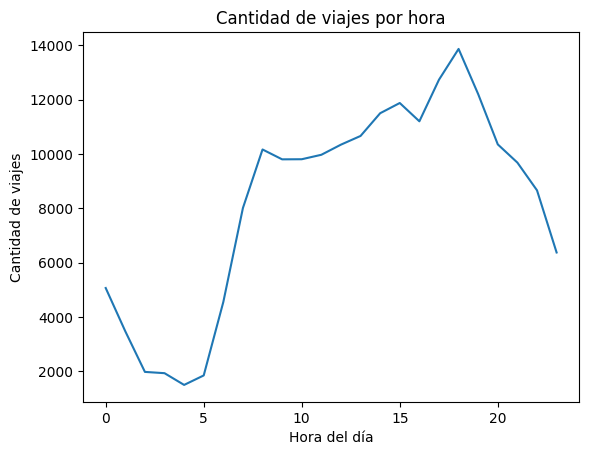

In [ ]:
df.groupby('hour').size().plot()
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de viajes")
plt.title("Cantidad de viajes por hora")

<Axes: xlabel='day'>

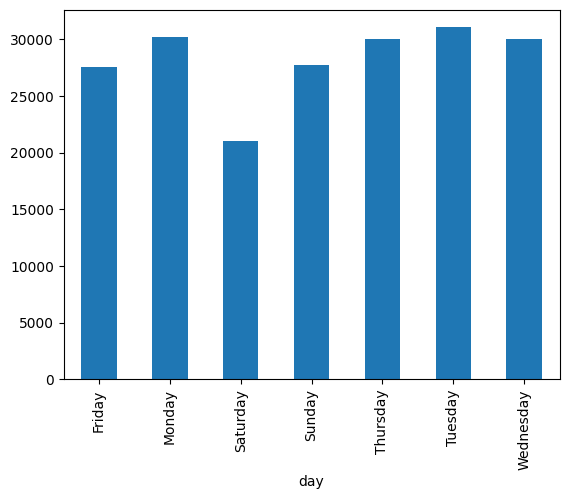

In [ ]:
df.groupby('day').size().plot(kind='bar')

##Ingresos

Text(0.5, 1.0, 'Tarifa media por hora')

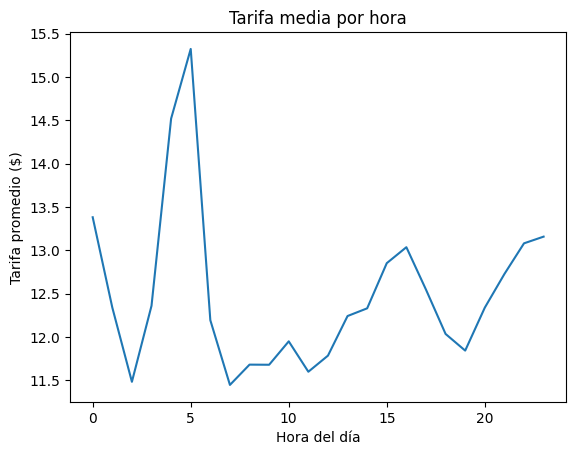

In [ ]:
df.groupby('hour')['fare_amount'].mean().plot()
plt.xlabel("Hora del día")
plt.ylabel("Tarifa promedio ($)")
plt.title("Tarifa media por hora")

<Axes: xlabel='trip_distance', ylabel='fare_amount'>

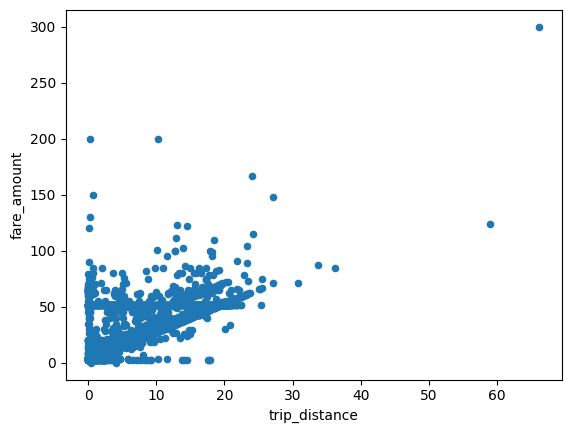

In [ ]:
df_cleantd.plot.scatter(x='trip_distance', y='fare_amount')

##Correlación

[Text(0, 0.5, 'Duración'), Text(0, 1.5, 'Distancia'), Text(0, 2.5, 'Tarifa')]

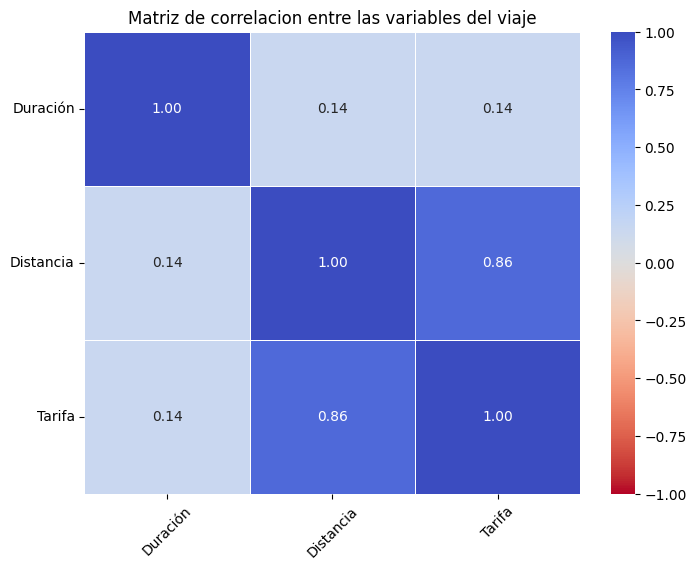

In [ ]:
corr_matrix=df[["trip_duration","trip_distance","fare_amount"]].corr()
plt.figure(figsize=(8,6))
px=sea.heatmap(corr_matrix, annot =True, vmin=-1, vmax=1, cmap="coolwarm_r", linewidths=0.5, fmt=".2f" )
plt.title("Matriz de correlacion entre las variables del viaje")
px.set_xticklabels([ "Duración","Distancia","Tarifa"], rotation=45)
px.set_yticklabels([ "Duración","Distancia","Tarifa"], rotation=0)

In [ ]:
#relacion entre cantidad de viajes por hora y tarifa por hora

trips_per_hour = df_cleantd.groupby('hour').size()
fare_per_hour = df_cleantd.groupby('hour')['fare_amount'].mean()
hourly_df = pd.DataFrame({
    'trips': trips_per_hour,
    'avg_fare': fare_per_hour
})

hourly_df.head()

,trips,avg_fare
hour,,
0,4909,12.489493
1,3300,11.643009
2,1949,11.187327
3,1899,12.024492
4,1456,13.704670


<Axes: xlabel='trips', ylabel='avg_fare'>

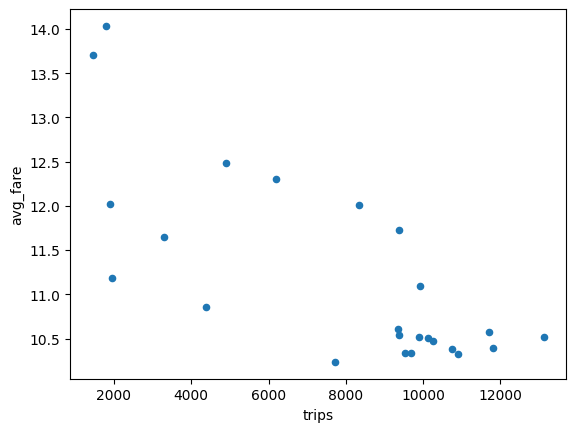

In [ ]:
hourly_df.plot.scatter(x='trips', y='avg_fare')

[Text(0, 0.5, 'Viajes por hora'), Text(0, 1.5, 'Tarifa promedio por hora')]

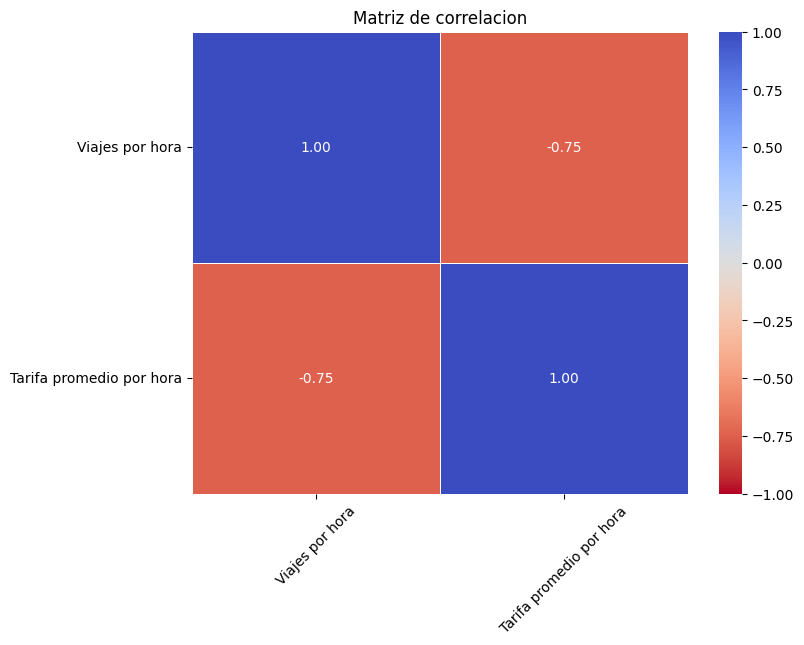

In [ ]:

plt.figure(figsize=(8,6))
ax=sea.heatmap(hourly_df.corr(), annot =True, vmin=-1, vmax=1, cmap="coolwarm_r", linewidths=0.5, fmt=".2f" )
plt.title("Cantidad de viajes y tarifa (ambas por hora)")


ax.set_xticklabels([ "Viajes por hora","Tarifa promedio por hora"], rotation=45)
ax.set_yticklabels([ "Viajes por hora","Tarifa promedio por hora"], rotation=0)

In [ ]:
fare_total = df.groupby('hour')['fare_amount'].sum()

hourly_df['total_fare'] = fare_total